In [6]:
import numpy as np
import random
from collections import Counter

np.random.seed(42)
random.seed(42)

# Configuration
n_samples = 10_000
max_array_len = 10
zipf_param = 2.0

# Generate Zipfian array lengths via rejection sampling
lengths = []
while len(lengths) < n_samples:
    batch = np.random.zipf(zipf_param, size=n_samples)
    valid = batch[(batch >= 1) & (batch <= max_array_len)]
    lengths.extend(valid.tolist())
lengths = lengths[:n_samples]

# Print distribution
length_counts = Counter(lengths)
print("Array length distribution:")
for k in sorted(length_counts):
    pct = length_counts[k] / n_samples * 100
    bar = "█" * int(pct)
    print(f"  {k:2d}: {length_counts[k]:5d} ({pct:5.1f}%) {bar}")

# Vocabularies
items = ["gold", "silver", "gem", "potion", "scroll", "ring", "amulet", "sword", "shield", "armor"]
regions = ["north", "south", "east", "west"]

# Generate dataset: "length" field determines array size
data = []
for i in range(n_samples):
    length = int(lengths[i])
    doc = {
        "region": random.choice(regions),
        "length": length,
        "treasure": random.choices(items, k=length),
    }
    data.append(doc)

# Train/eval split
split = int(0.9 * n_samples)
train_data = data[:split]
eval_data = data[split:]

print(f"\nTrain: {len(train_data)}, Eval: {len(eval_data)}")
print(f"\nSample documents:")
for doc in data[:5]:
    print(f"  {doc}")

Array length distribution:
   1:  6430 ( 64.3%) ████████████████████████████████████████████████████████████████
   2:  1645 ( 16.4%) ████████████████
   3:   719 (  7.2%) ███████
   4:   438 (  4.4%) ████
   5:   248 (  2.5%) ██
   6:   168 (  1.7%) █
   7:   129 (  1.3%) █
   8:    94 (  0.9%) 
   9:    64 (  0.6%) 
  10:    65 (  0.7%) 

Train: 9000, Eval: 1000

Sample documents:
  {'region': 'north', 'length': 1, 'treasure': ['gold']}
  {'region': 'east', 'length': 3, 'treasure': ['gem', 'silver', 'silver']}
  {'region': 'north', 'length': 1, 'treasure': ['ring']}
  {'region': 'north', 'length': 1, 'treasure': ['gold']}
  {'region': 'south', 'length': 2, 'treasure': ['gem', 'amulet']}


In [8]:
from origami import ModelConfig, OrigamiConfig, OrigamiPipeline, TrainingConfig
from origami.config import DataConfig
from origami.training import TableLogCallback

config = OrigamiConfig(
    data=DataConfig(
        infer_schema=True,
        numeric_mode="disabled",
    ),
    model=ModelConfig(
        backbone="transformer",
        kvpe_pooling="sum",
        d_model=64,
        n_heads=8,
        n_layers=6,
        d_ff=784,
        dropout=0.0,
    ),
    training=TrainingConfig(
        shuffle_keys=False,
        batch_size=64,
        warmup_steps=1000,
        learning_rate=1e-3,
        constrain_grammar=True,
        constrain_schema=True,
    ),
    device="mps",
)

pipeline = OrigamiPipeline(config)


In [9]:
pipeline.fit(
    train_data,
    # eval_data=eval_data,
    callbacks=[TableLogCallback(print_every=100)],
    epochs=30,
    verbose=True,
)


Vocabulary size: 37
Derived schema:
{
  "type": "object",
  "properties": {
    "length": {
      "type": "integer",
      "enum": [
        1,
        2,
        3,
        4,
        5,
        "... + 5 more"
      ],
      "minimum": 1,
      "maximum": 10
    },
    "region": {
      "type": "string",
      "enum": [
        "east",
        "north",
        "south",
        "west"
      ]
    },
    "treasure": {
      "type": "array",
      "items": {
        "type": "string",
        "enum": [
          "amulet",
          "armor",
          "gem",
          "gold",
          "potion",
          "... + 5 more"
        ]
      },
      "minItems": 1,
      "maxItems": 10
    }
  },
  "additionalProperties": false,
  "required": [
    "length",
    "region",
    "treasure"
  ]
}
Model parameters: 729,861
Training device: mps
| step: 100 | epoch: 0 | lr: 1.00e-04 | batch_dt:  28ms | loss: 0.6880 |
| step: 200 | epoch: 1 | lr: 2.00e-04 | batch_dt:  17ms | loss: 0.6177 |
| step: 300 |

OrigamiPipeline(numeric_mode='disabled', fitted)

Generated 1000 samples, 1000 have both fields

Sample generated docs:
  {'region': 'south', 'length': 1, 'treasure': ['gold']}
  {'region': 'west', 'length': 2, 'treasure': ['potion', 'armor']}
  {'region': 'south', 'length': 1, 'treasure': ['silver']}
  {'region': 'south', 'length': 4, 'treasure': ['shield', 'potion', 'amulet', 'silver']}
  {'region': 'west', 'length': 1, 'treasure': ['gold']}


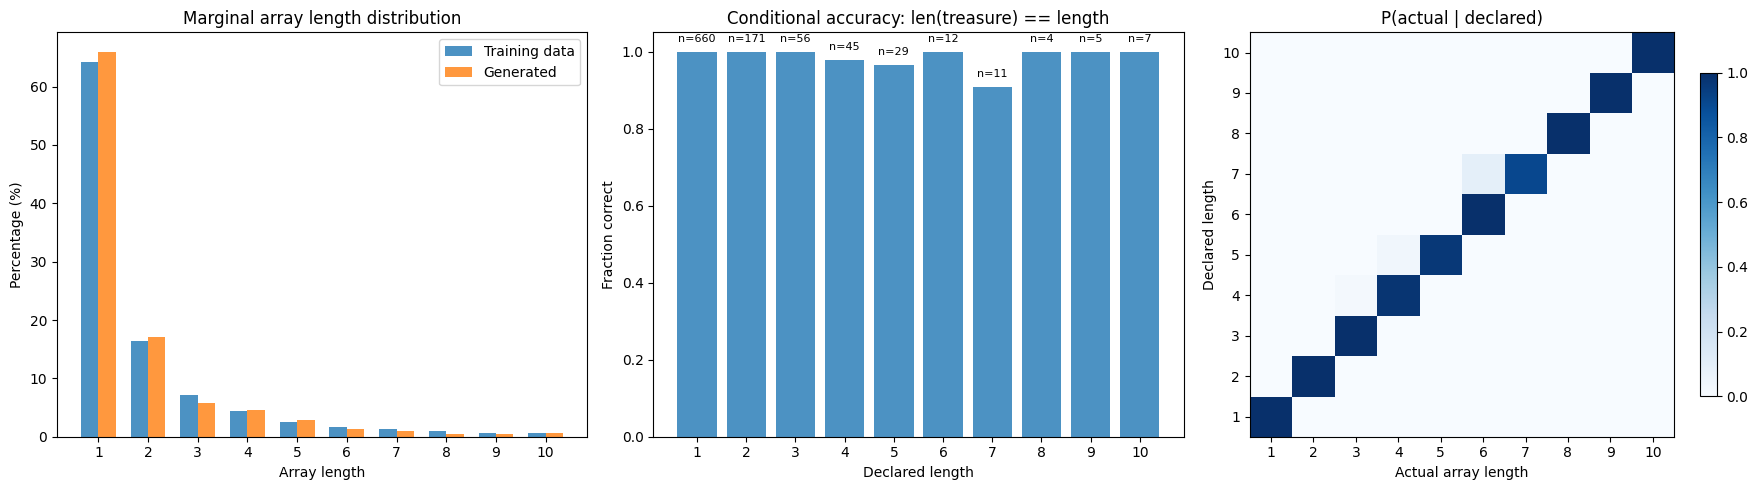


Overall conditional accuracy: 99.7%


In [10]:
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# Generate samples
n_gen = 1000
generated = pipeline.generate(num_samples=n_gen, temperature=1.0)

# Filter to valid samples
valid = [d for d in generated if "treasure" in d and "length" in d]
print(f"Generated {len(generated)} samples, {len(valid)} have both fields")
print(f"\nSample generated docs:")
for doc in generated[:5]:
    print(f"  {doc}")

# --- Plot 1: Overall array length distribution ---
train_lengths = [len(d["treasure"]) for d in train_data]
gen_lengths = [len(d["treasure"]) for d in valid]

train_counts = Counter(train_lengths)
gen_counts = Counter(gen_lengths)
train_pcts = [train_counts.get(k, 0) / len(train_lengths) * 100 for k in range(1, max_array_len + 1)]
gen_pcts = [gen_counts.get(k, 0) / max(len(gen_lengths), 1) * 100 for k in range(1, max_array_len + 1)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = range(1, max_array_len + 1)
width = 0.35
axes[0].bar([i - width / 2 for i in x], train_pcts, width, label="Training data", alpha=0.8)
axes[0].bar([i + width / 2 for i in x], gen_pcts, width, label="Generated", alpha=0.8)
axes[0].set_xlabel("Array length")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_title("Marginal array length distribution")
axes[0].set_xticks(list(x))
axes[0].legend()

# --- Plot 2: Conditional accuracy (does len(treasure) == length?) ---
correct_by_length = defaultdict(list)
for d in valid:
    declared = d["length"]
    actual = len(d["treasure"])
    correct_by_length[declared].append(actual == declared)

declared_lengths = sorted(correct_by_length.keys())
accuracies = [sum(correct_by_length[k]) / len(correct_by_length[k]) for k in declared_lengths]
counts = [len(correct_by_length[k]) for k in declared_lengths]

bars = axes[1].bar(declared_lengths, accuracies, alpha=0.8)
axes[1].set_xlabel("Declared length")
axes[1].set_ylabel("Fraction correct")
axes[1].set_title("Conditional accuracy: len(treasure) == length")
axes[1].set_xticks(declared_lengths)
axes[1].set_ylim(0, 1.05)
# Annotate with sample counts
for bar, n in zip(bars, counts):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"n={n}", ha="center", va="bottom", fontsize=8
    )

# --- Plot 3: Heatmap of declared vs actual length ---
max_len = max(max(d["length"] for d in valid), max(len(d["treasure"]) for d in valid))
heatmap = np.zeros((max_len, max_len))
for d in valid:
    declared = d["length"]
    actual = len(d["treasure"])
    if declared <= max_len and actual <= max_len:
        heatmap[declared - 1, actual - 1] += 1

# Normalize each row to show distribution per declared length
row_sums = heatmap.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
heatmap_norm = heatmap / row_sums

im = axes[2].imshow(heatmap_norm, origin="lower", aspect="auto", cmap="Blues")
axes[2].set_xlabel("Actual array length")
axes[2].set_ylabel("Declared length")
axes[2].set_title("P(actual | declared)")
axes[2].set_xticks(range(max_len))
axes[2].set_xticklabels(range(1, max_len + 1))
axes[2].set_yticks(range(max_len))
axes[2].set_yticklabels(range(1, max_len + 1))
fig.colorbar(im, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()

# Print summary
overall_acc = sum(len(d["treasure"]) == d["length"] for d in valid) / len(valid)
print(f"\nOverall conditional accuracy: {overall_acc:.1%}")